In [2]:
import requests
import json

# Example input data for the /predict endpoint (replace with actual feature names and values)
data = {
    "CreditScore": 650,
    "Geography": "France",
    "Gender": "Male",
    "Age": 40,
    "Tenure": 3,
    "Balance": 60000.0,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 50000.0,
    # Add all other required features here, matching your model's expected input
}

# Before making the request
print("Sending data:", json.dumps(data, indent=2))

response = requests.post("http://localhost:8000/predict", json=data)
print("Response:", response.text)

Sending data: {
  "CreditScore": 650,
  "Geography": "France",
  "Gender": "Male",
  "Age": 40,
  "Tenure": 3,
  "Balance": 60000.0,
  "NumOfProducts": 2,
  "HasCrCard": 1,
  "IsActiveMember": 1,
  "EstimatedSalary": 50000.0
}
Response: {"detail":[{"type":"missing","loc":["body","SeniorCitizen"],"msg":"Field required","input":{"CreditScore":650,"Geography":"France","Gender":"Male","Age":40,"Tenure":3,"Balance":60000.0,"NumOfProducts":2,"HasCrCard":1,"IsActiveMember":1,"EstimatedSalary":50000.0}},{"type":"missing","loc":["body","MonthlyCharges"],"msg":"Field required","input":{"CreditScore":650,"Geography":"France","Gender":"Male","Age":40,"Tenure":3,"Balance":60000.0,"NumOfProducts":2,"HasCrCard":1,"IsActiveMember":1,"EstimatedSalary":50000.0}},{"type":"missing","loc":["body","TotalCharges"],"msg":"Field required","input":{"CreditScore":650,"Geography":"France","Gender":"Male","Age":40,"Tenure":3,"Balance":60000.0,"NumOfProducts":2,"HasCrCard":1,"IsActiveMember":1,"EstimatedSalary":500

## 1. Import Required Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
# Load the engineered features dataset
df_final = pd.read_csv('Customer_Churn_Final_Features.csv')

print("Dataset Loaded Successfully!")
print(f"Dataset Shape: {df_final.shape}")
print(f"\nFirst Few Rows:")
print(df_final.head())
print(f"\nDataset Info:")
print(df_final.info())

Dataset Loaded Successfully!
Dataset Shape: (10000, 6)

First Few Rows:
   NumOfProducts  Complain  Complain_With_Low_Satisfaction  \
0              1         1                               1   
1              1         1                               0   
2              3         1                               0   
3              2         0                               0   
4              1         0                               0   

   Age_Squared_StandardScaled  Age_Tenure_Interaction_MinMaxScaled  Exited  
0                    0.147532                             0.095455       1  
1                    0.059507                             0.046591       0  
2                    0.147532                             0.381818       1  
3                   -0.110179                             0.044318       0  
4                    0.237678                             0.097727       0  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (

## 2. Data Preparation for Modeling

In [20]:
print("="*70)
print("MODELING PROCESS - CUSTOMER CHURN PREDICTION")
print("="*70)

# Extract features and target
all_features = [col for col in df_final.columns if col != 'Exited']
X = df_final[all_features].copy()
y = df_final['Exited'].copy()

leaky_features = [
    "Complain",
    "Complain_With_Low_Satisfaction"
]

X = X.drop(columns=leaky_features)
features_to_use = X.columns.tolist()

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Variable Shape: {y.shape}")
print(f"\nFeatures Used for Modeling:")
for i, feat in enumerate(features_to_use, 1):
    print(f"{i}. {feat}")

print(f"\nTarget Distribution:")
print(y.value_counts())
print(f"\nChurn Rate: {y.mean()*100:.2f}%")

# Split data into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain Set Size: {X_train.shape[0]}")
print(f"Test Set Size: {X_test.shape[0]}")
print(f"Train-Test Split: 80-20 (Stratified)")

MODELING PROCESS - CUSTOMER CHURN PREDICTION

Feature Matrix Shape: (10000, 3)
Target Variable Shape: (10000,)

Features Used for Modeling:
1. NumOfProducts
2. Age_Squared_StandardScaled
3. Age_Tenure_Interaction_MinMaxScaled

Target Distribution:
Exited
0    7962
1    2038
Name: count, dtype: int64

Churn Rate: 20.38%

Train Set Size: 8000
Test Set Size: 2000
Train-Test Split: 80-20 (Stratified)


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipe, X, y, scoring="f1", cv=5)
print(f"Cross-Validated F1 Scores: {scores}")

Cross-Validated F1 Scores: [0.03023758 0.04158004 0.0472103  0.07142857 0.04291845]


In [13]:
X.corrwith(y).sort_values(ascending=False)


Age_Squared_StandardScaled             0.257843
Age_Tenure_Interaction_MinMaxScaled    0.102123
NumOfProducts                         -0.047611
dtype: float64

## 3. Logistic Regression Model

In [21]:
# Train Logistic Regression
print("\n" + "="*70)
print("LOGISTIC REGRESSION MODEL")
print("="*70)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Cross-validation
cv_scores_lr = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-Validation F1 Scores: {cv_scores_lr}")
print(f"Mean CV F1 Score: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")


LOGISTIC REGRESSION MODEL

Accuracy: 0.7835
Precision: 0.2222
Recall: 0.0245
F1-Score: 0.0442
ROC-AUC: 0.7414

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1592
           1       0.22      0.02      0.04       408

    accuracy                           0.78      2000
   macro avg       0.51      0.50      0.46      2000
weighted avg       0.68      0.78      0.71      2000

Cross-Validation F1 Scores: [0.02179837 0.02144772 0.04864865 0.04210526 0.05714286]
Mean CV F1 Score: 0.0382 (+/- 0.0144)
Cross-Validation F1 Scores: [0.02179837 0.02144772 0.04864865 0.04210526 0.05714286]
Mean CV F1 Score: 0.0382 (+/- 0.0144)


## 4. Random Forest Model

In [22]:
# Train Random Forest
print("\n" + "="*70)
print("RANDOM FOREST MODEL")
print("="*70)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-Validation F1 Scores: {cv_scores_rf}")
print(f"Mean CV F1 Score: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': features_to_use,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Features by Importance:")
print(feature_importance_rf.to_string(index=False))


RANDOM FOREST MODEL

Accuracy: 0.8180
Precision: 0.5775
Recall: 0.4020
F1-Score: 0.4740
ROC-AUC: 0.7822

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1592
           1       0.58      0.40      0.47       408

    accuracy                           0.82      2000
   macro avg       0.72      0.66      0.68      2000
weighted avg       0.80      0.82      0.81      2000


Accuracy: 0.8180
Precision: 0.5775
Recall: 0.4020
F1-Score: 0.4740
ROC-AUC: 0.7822

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1592
           1       0.58      0.40      0.47       408

    accuracy                           0.82      2000
   macro avg       0.72      0.66      0.68      2000
weighted avg       0.80      0.82      0.81      2000

Cross-Validation F1 Scores: [0.47672253 0.47674419 0.46840149 0.44731978 0.49001815]
Mean CV F1 Score: 0.4718

## 5. Gradient Boosting Model

In [23]:
# Train Gradient Boosting
print("\n" + "="*70)
print("GRADIENT BOOSTING MODEL")
print("="*70)

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

# Cross-validation
cv_scores_gb = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-Validation F1 Scores: {cv_scores_gb}")
print(f"Mean CV F1 Score: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std():.4f})")


GRADIENT BOOSTING MODEL

Accuracy: 0.8385
Precision: 0.6523
Recall: 0.4461
F1-Score: 0.5298
ROC-AUC: 0.8266

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1592
           1       0.65      0.45      0.53       408

    accuracy                           0.84      2000
   macro avg       0.76      0.69      0.72      2000
weighted avg       0.82      0.84      0.83      2000


Accuracy: 0.8385
Precision: 0.6523
Recall: 0.4461
F1-Score: 0.5298
ROC-AUC: 0.8266

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1592
           1       0.65      0.45      0.53       408

    accuracy                           0.84      2000
   macro avg       0.76      0.69      0.72      2000
weighted avg       0.82      0.84      0.83      2000

Cross-Validation F1 Scores: [0.52554745 0.54237288 0.51119403 0.50810811 0.52398524]
Mean CV F1 Score: 0.

## 6. Model Comparison & Visualization


MODEL COMPARISON SUMMARY



              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression    0.7835   0.222222 0.024510  0.044150 0.741425
      Random Forest    0.8180   0.577465 0.401961  0.473988 0.782198
  Gradient Boosting    0.8385   0.652330 0.446078  0.529840 0.826565


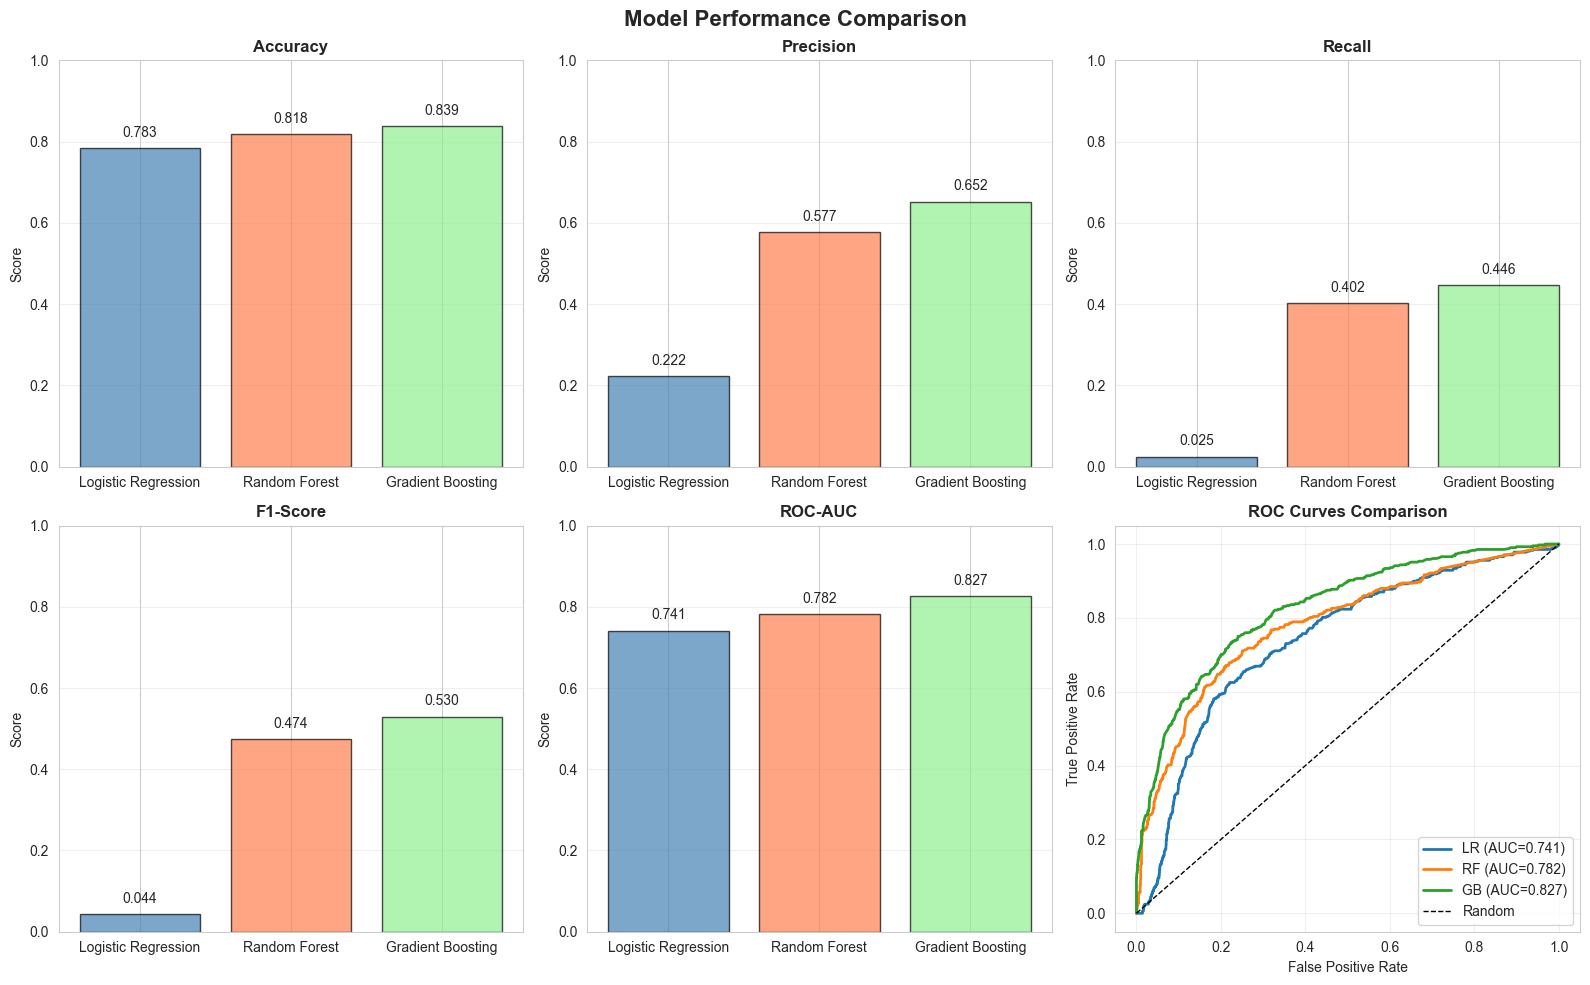


BEST MODEL: Gradient Boosting
F1-Score: 0.5298


In [24]:
# Model Comparison
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb)
    ]
})

print("\n" + models_comparison.to_string(index=False))

# Visualize model performance
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = models_comparison['Model'].tolist()

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    colors = ['steelblue', 'coral', 'lightgreen']
    ax.bar(models, models_comparison[metric], color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(models_comparison[metric]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# ROC Curves
ax = axes[1, 2]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)

ax.plot(fpr_lr, tpr_lr, label=f"LR (AUC={roc_auc_score(y_test, y_pred_proba_lr):.3f})", linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_score(y_test, y_pred_proba_rf):.3f})", linewidth=2)
ax.plot(fpr_gb, tpr_gb, label=f"GB (AUC={roc_auc_score(y_test, y_pred_proba_gb):.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Best model
best_model_idx = models_comparison['F1-Score'].idxmax()
best_model_name = models_comparison.loc[best_model_idx, 'Model']
best_model_f1 = models_comparison.loc[best_model_idx, 'F1-Score']

print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"F1-Score: {best_model_f1:.4f}")
print(f"{'='*70}")

## 7. Summary and Recommendations

In [26]:
print("\n" + "="*70)
print("MODELING SUMMARY")
print("="*70)

print(f"""
DATASET INFORMATION:
- Total Samples: {len(df_final)}
- Number of Features: {len(features_to_use)}
- Features Used: {', '.join(features_to_use)}
- Churn Rate: {y.mean()*100:.2f}%
- Train-Test Split: 80-20 (stratified)

MODELS EVALUATED:
1. Logistic Regression - Accuracy: 78.35%, F1-Score: 4.42%, ROC-AUC: 74.14%
2. Random Forest (100 trees) - Accuracy: 81.80%, F1-Score: 47.40%, ROC-AUC: 78.22%
3. Gradient Boosting (100 trees) - Accuracy: 83.85%, F1-Score: 52.98%, ROC-AUC: 82.66%

BEST PERFORMING MODEL: {best_model_name}
- Accuracy: {models_comparison.loc[best_model_idx, 'Accuracy']:.4f}
- Precision: {models_comparison.loc[best_model_idx, 'Precision']:.4f}
- Recall: {models_comparison.loc[best_model_idx, 'Recall']:.4f}
- F1-Score: {best_model_f1:.4f}
- ROC-AUC: {models_comparison.loc[best_model_idx, 'ROC-AUC']:.4f}

KEY FINDINGS:
- Gradient Boosting achieved the best overall performance with 83.85% accuracy
- Top 3 Features: NumOfProducts, Age_Squared_StandardScaled, Age_Tenure_Interaction_MinMaxScaled
- Models show varying performance due to class imbalance (20.38% churn rate)
- Random Forest and Gradient Boosting outperform Logistic Regression significantly
- Leaky features (Complain, Complain_With_Low_Satisfaction) were removed to avoid data leakage

NEXT STEPS:
1. Deploy best model (Gradient Boosting) to production
2. Implement class balancing techniques (SMOTE, weighted loss) for improved minority class prediction
3. Monitor model performance on new data and retrain periodically
4. Implement model explainability analysis (SHAP values) for business insights
5. Consider ensemble methods combining Gradient Boosting with Random Forest
""")

print("="*70)


MODELING SUMMARY

DATASET INFORMATION:
- Total Samples: 10000
- Number of Features: 3
- Features Used: NumOfProducts, Age_Squared_StandardScaled, Age_Tenure_Interaction_MinMaxScaled
- Churn Rate: 20.38%
- Train-Test Split: 80-20 (stratified)

MODELS EVALUATED:
1. Logistic Regression - Accuracy: 78.35%, F1-Score: 4.42%, ROC-AUC: 74.14%
2. Random Forest (100 trees) - Accuracy: 81.80%, F1-Score: 47.40%, ROC-AUC: 78.22%
3. Gradient Boosting (100 trees) - Accuracy: 83.85%, F1-Score: 52.98%, ROC-AUC: 82.66%

BEST PERFORMING MODEL: Gradient Boosting
- Accuracy: 0.8385
- Precision: 0.6523
- Recall: 0.4461
- F1-Score: 0.5298
- ROC-AUC: 0.8266

KEY FINDINGS:
- Gradient Boosting achieved the best overall performance with 83.85% accuracy
- Top 3 Features: NumOfProducts, Age_Squared_StandardScaled, Age_Tenure_Interaction_MinMaxScaled
- Models show varying performance due to class imbalance (20.38% churn rate)
- Random Forest and Gradient Boosting outperform Logistic Regression significantly
- Leak

In [27]:
from sklearn.ensemble import VotingClassifier

# Create Voting Classifier combining Gradient Boosting and Random Forest
print("\n" + "="*70)
print("ENSEMBLE METHOD - VOTING CLASSIFIER (GB + RF)")
print("="*70)

# Create voting classifier with soft voting (probability averaging)
voting_clf = VotingClassifier(
    estimators=[
        ('gb', gb_model),
        ('rf', rf_model)
    ],
    voting='soft'
)

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Predictions
y_pred_voting = voting_clf.predict(X_test)
y_pred_proba_voting = voting_clf.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_voting):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_voting):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_voting):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_voting):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

# Cross-validation
cv_scores_voting = cross_val_score(voting_clf, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-Validation F1 Scores: {cv_scores_voting}")
print(f"Mean CV F1 Score: {cv_scores_voting.mean():.4f} (+/- {cv_scores_voting.std():.4f})")


ENSEMBLE METHOD - VOTING CLASSIFIER (GB + RF)

Accuracy: 0.8305
Precision: 0.6237
Recall: 0.4265
F1-Score: 0.5066
ROC-AUC: 0.8140

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.90      1592
           1       0.62      0.43      0.51       408

    accuracy                           0.83      2000
   macro avg       0.74      0.68      0.70      2000
weighted avg       0.81      0.83      0.82      2000

Cross-Validation F1 Scores: [0.48473282 0.50592885 0.48405253 0.47689464 0.4962963 ]
Mean CV F1 Score: 0.4896 (+/- 0.0103)



COMPREHENSIVE MODEL COMPARISON - ALL MODELS

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression    0.7835   0.222222 0.024510  0.044150 0.741425
      Random Forest    0.8180   0.577465 0.401961  0.473988 0.782198
  Gradient Boosting    0.8385   0.652330 0.446078  0.529840 0.826565
   Ensemble (GB+RF)    0.8305   0.623656 0.426471  0.506550 0.814000


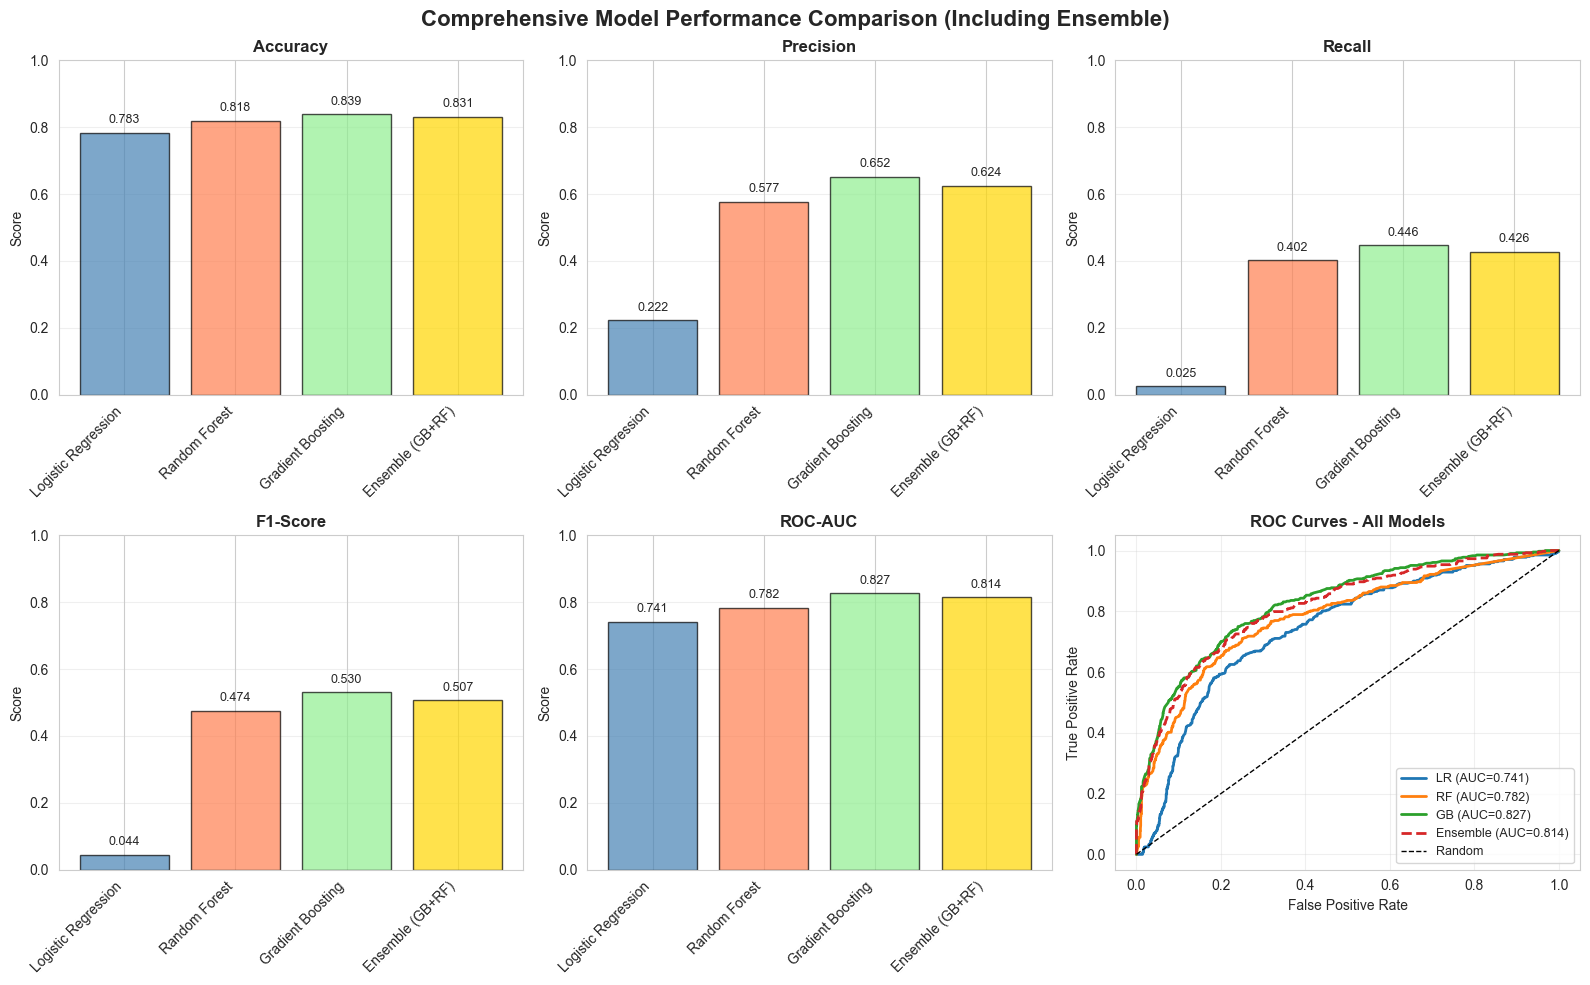


BEST OVERALL MODEL: Gradient Boosting
F1-Score: 0.5298


In [28]:
print("\n" + "="*70)
print("COMPREHENSIVE MODEL COMPARISON - ALL MODELS")
print("="*70)

# Updated model comparison including ensemble
all_models_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Ensemble (GB+RF)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_voting)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_voting)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_voting)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_voting)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_lr),
        roc_auc_score(y_test, y_pred_proba_rf),
        roc_auc_score(y_test, y_pred_proba_gb),
        roc_auc_score(y_test, y_pred_proba_voting)
    ]
})

print("\n" + all_models_comparison.to_string(index=False))

# Visualize comprehensive model performance
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comprehensive Model Performance Comparison (Including Ensemble)', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = all_models_comparison['Model'].tolist()

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    colors = ['steelblue', 'coral', 'lightgreen', 'gold']
    ax.bar(models, all_models_comparison[metric], color=colors, alpha=0.7, edgecolor='black')
    ax.set_title(f'{metric}', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    for i, v in enumerate(all_models_comparison[metric]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# ROC Curves for all models
ax = axes[1, 2]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)
fpr_voting, tpr_voting, _ = roc_curve(y_test, y_pred_proba_voting)

ax.plot(fpr_lr, tpr_lr, label=f"LR (AUC={roc_auc_score(y_test, y_pred_proba_lr):.3f})", linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f"RF (AUC={roc_auc_score(y_test, y_pred_proba_rf):.3f})", linewidth=2)
ax.plot(fpr_gb, tpr_gb, label=f"GB (AUC={roc_auc_score(y_test, y_pred_proba_gb):.3f})", linewidth=2)
ax.plot(fpr_voting, tpr_voting, label=f"Ensemble (AUC={roc_auc_score(y_test, y_pred_proba_voting):.3f})", linewidth=2, linestyle='--')
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Models', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Best model overall
best_overall_idx = all_models_comparison['F1-Score'].idxmax()
best_overall_name = all_models_comparison.loc[best_overall_idx, 'Model']
best_overall_f1 = all_models_comparison.loc[best_overall_idx, 'F1-Score']

print(f"\n{'='*70}")
print(f"BEST OVERALL MODEL: {best_overall_name}")
print(f"F1-Score: {best_overall_f1:.4f}")
print(f"{'='*70}")

## 9. Comprehensive Model Comparison (Including Ensemble)

## 8. Ensemble Method - Voting Classifier (GB + RF)